# 🎬 Using Data Mining to Make Recommendations for Movies to Watch for Any Viewers

---

## Project Overview

This project builds a **Movie Recommendation System** using data mining techniques applied to the **IMDb dataset** (`title.basics.tsv.gz` and `title.episode.tsv.gz`). Since no explicit user-rating data is available, we implement:

- **Content-Based Filtering** using TF-IDF on genres and metadata
- **Genre-Based Association Rules** (Apriori Algorithm) for co-occurrence mining
- **Popularity-Based Ranking** using weighted scoring
- **Hybrid Recommender** combining content similarity + popularity
- **Clustering (K-Means)** to group movies into thematic clusters

### Datasets Used
| File | Description |
|------|-------------|
| `title.basics.tsv.gz` | Movie metadata: title, type, year, runtime, genres |
| `title.episode.tsv.gz` | Episode info: links episodes to parent TV series |

---

## 📦 Step 1: Install & Import Libraries

In [ ]:
# Install required libraries (run once)
! pip install mlxtend scikit-learn pandas numpy matplotlib seaborn --quiet

zsh:1: command not found: pip


In [3]:
%pip install mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import TruncatedSVD

# Apriori
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print("✅ All libraries loaded successfully!")

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.4 MB 209 kB/s eta 0:00:01
     |████████████████████████████████| 1.4 MB 417 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
✅ All libraries loaded successfully!


---
## 📂 Step 2: Load the Datasets

In [6]:
# ─── LOAD title.basics ───────────────────────────────────────────────────────
print("Loading title.basics.tsv.gz ...")
basics = pd.read_csv(
    'title.basics.tsv',
    sep='\t',
    na_values='\\N',
    low_memory=False
    
)
print(f"  title.basics shape: {basics.shape}")

# ─── LOAD title.episode ──────────────────────────────────────────────────────
print("Loading title.episode.tsv.gz ...")
episodes = pd.read_csv(
    'title.episode.tsv',
    sep='\t',
    na_values='\\N',
    low_memory=False
)
print(f"  title.episode shape: {episodes.shape}")

Loading title.basics.tsv.gz ...
  title.basics shape: (12339113, 9)
Loading title.episode.tsv.gz ...
  title.episode shape: (9523422, 4)


In [7]:
print("=== title.basics — First 5 rows ===")
display(basics.head())

print("\n=== title.episode — First 5 rows ===")
display(episodes.head())

=== title.basics — First 5 rows ===


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short



=== title.episode — First 5 rows ===


,tconst,parentTconst,seasonNumber,episodeNumber
0,tt0031458,tt32857063,NaN,NaN
1,tt0041951,tt0041038,1.0,9.0
2,tt0042816,tt0989125,1.0,17.0
3,tt0042889,tt0989125,NaN,NaN
4,tt0043426,tt0040051,3.0,42.0


---
## 🧹 Step 3: Data Preprocessing

We will:
1. Filter to **movies only** (titleType == 'movie')
2. Handle missing values (`\N` → NaN → fill/drop)
3. Convert data types
4. Engineer features for recommendation
5. Remove duplicates and noisy records

In [8]:
# ─── 3.1  Inspect missing values ─────────────────────────────────────────────
print("=== Missing values in title.basics ===")
print(basics.isnull().sum())
print(f"\nTotal records: {len(basics)}")

=== Missing values in title.basics ===
tconst                   0
titleType                0
primaryTitle            25
originalTitle           25
isAdult                  0
startYear          1455695
endYear           12185220
runtimeMinutes     7908999
genres              534264
dtype: int64

Total records: 12339113


In [9]:
# ─── 3.2  Filter to movies only ──────────────────────────────────────────────
movies = basics[basics['titleType'] == 'movie'].copy()
print(f"Movies only: {len(movies)} records")

# ─── 3.3  Drop rows where primaryTitle or genres is missing ──────────────────
movies.dropna(subset=['primaryTitle', 'genres'], inplace=True)
print(f"After dropping missing title/genre rows: {len(movies)}")

# ─── 3.4  Convert numeric columns ────────────────────────────────────────────
movies['startYear']      = pd.to_numeric(movies['startYear'],      errors='coerce')
movies['runtimeMinutes'] = pd.to_numeric(movies['runtimeMinutes'], errors='coerce')
movies['isAdult']        = pd.to_numeric(movies['isAdult'],        errors='coerce').fillna(0).astype(int)

# ─── 3.5  Filter out adult content ───────────────────────────────────────────
movies = movies[movies['isAdult'] == 0].copy()
print(f"After removing adult titles: {len(movies)}")

# ─── 3.6  Fill remaining numeric NaNs with median ────────────────────────────
movies['startYear'].fillna(movies['startYear'].median(), inplace=True)
movies['runtimeMinutes'].fillna(movies['runtimeMinutes'].median(), inplace=True)

# ─── 3.7  Remove duplicates ───────────────────────────────────────────────────
movies.drop_duplicates(subset=['tconst'], inplace=True)
movies.reset_index(drop=True, inplace=True)

print(f"\n✅ Final clean movie dataset: {movies.shape}")
display(movies.head())

Movies only: 739633 records
After dropping missing title/genre rows: 661900
After removing adult titles: 652680

✅ Final clean movie dataset: (652680, 9)


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000009,movie,Miss Jerry,Miss Jerry,0,1894.0,NaN,45.0,Romance
1,tt0000147,movie,The Corbett-Fitzsimmons Fight,The Corbett-Fitzsimmons Fight,0,1897.0,NaN,100.0,"Documentary,News,Sport"
2,tt0000574,movie,The Story of the Kelly Gang,The Story of the Kelly Gang,0,1906.0,NaN,70.0,"Action,Adventure,Biography"
3,tt0000591,movie,The Prodigal Son,L'enfant prodigue,0,1907.0,NaN,90.0,Drama
4,tt0000615,movie,Robbery Under Arms,Robbery Under Arms,0,1907.0,NaN,90.0,Drama


In [10]:
# ─── 3.8  Preprocess episodes dataset ────────────────────────────────────────
episodes.dropna(subset=['tconst', 'parentTconst'], inplace=True)
episodes['seasonNumber']  = pd.to_numeric(episodes['seasonNumber'],  errors='coerce')
episodes['episodeNumber'] = pd.to_numeric(episodes['episodeNumber'], errors='coerce')
episodes.drop_duplicates(subset=['tconst'], inplace=True)
episodes.reset_index(drop=True, inplace=True)

print(f"✅ Clean episode dataset: {episodes.shape}")
display(episodes.head())

✅ Clean episode dataset: (9523422, 4)


,tconst,parentTconst,seasonNumber,episodeNumber
0,tt0031458,tt32857063,NaN,NaN
1,tt0041951,tt0041038,1.0,9.0
2,tt0042816,tt0989125,1.0,17.0
3,tt0042889,tt0989125,NaN,NaN
4,tt0043426,tt0040051,3.0,42.0


In [11]:
# ─── 3.9  Feature Engineering ─────────────────────────────────────────────────

# Genre list (split comma-separated)
movies['genre_list'] = movies['genres'].str.split(',')

# Genre count
movies['genre_count'] = movies['genre_list'].apply(len)

# Era / decade
movies['decade'] = (movies['startYear'] // 10 * 10).astype(int)

# Combined feature string for TF-IDF (genres + decade)
movies['features'] = (
    movies['genres'].str.replace(',', ' ') + ' ' +
    movies['decade'].astype(str)
)

# Popularity proxy: shorter runtime AND more genres → slightly higher score
# (A real dataset would include vote counts — here we synthesise a proxy)
scaler = MinMaxScaler()
movies['runtime_scaled'] = scaler.fit_transform(movies[['runtimeMinutes']])
movies['genre_score']    = scaler.fit_transform(movies[['genre_count']])
movies['popularity_score'] = (0.6 * movies['runtime_scaled'] + 0.4 * movies['genre_score']).round(4)

print("✅ Feature engineering complete.")
display(movies[['tconst','primaryTitle','genres','decade','features','popularity_score']].head(10))

✅ Feature engineering complete.


,tconst,primaryTitle,genres,decade,features,popularity_score
0,tt0000009,Miss Jerry,Romance,1890,Romance 1890,0.0005
1,tt0000147,The Corbett-Fitzsimmons Fight,"Documentary,News,Sport",1890,Documentary News Sport 1890,0.4012
2,tt0000574,The Story of the Kelly Gang,"Action,Adventure,Biography",1900,Action Adventure Biography 1900,0.4008
3,tt0000591,The Prodigal Son,Drama,1900,Drama 1900,0.0010
4,tt0000615,Robbery Under Arms,Drama,1900,Drama 1900,0.0010
5,tt0000630,Hamlet,Drama,1900,Drama 1900,0.0010
6,tt0000675,Don Quijote,Drama,1900,Drama 1900,0.0010
7,tt0000679,The Fairylogue and Radio-Plays,"Adventure,Fantasy",1900,Adventure Fantasy 1900,0.2014
8,tt0000886,"Hamlet, Prince of Denmark",Drama,1910,Drama 1910,0.0010
9,tt0000941,Locura de amor,Drama,1900,Drama 1900,0.0005


---
## 📊 Step 4: Exploratory Data Analysis (EDA)

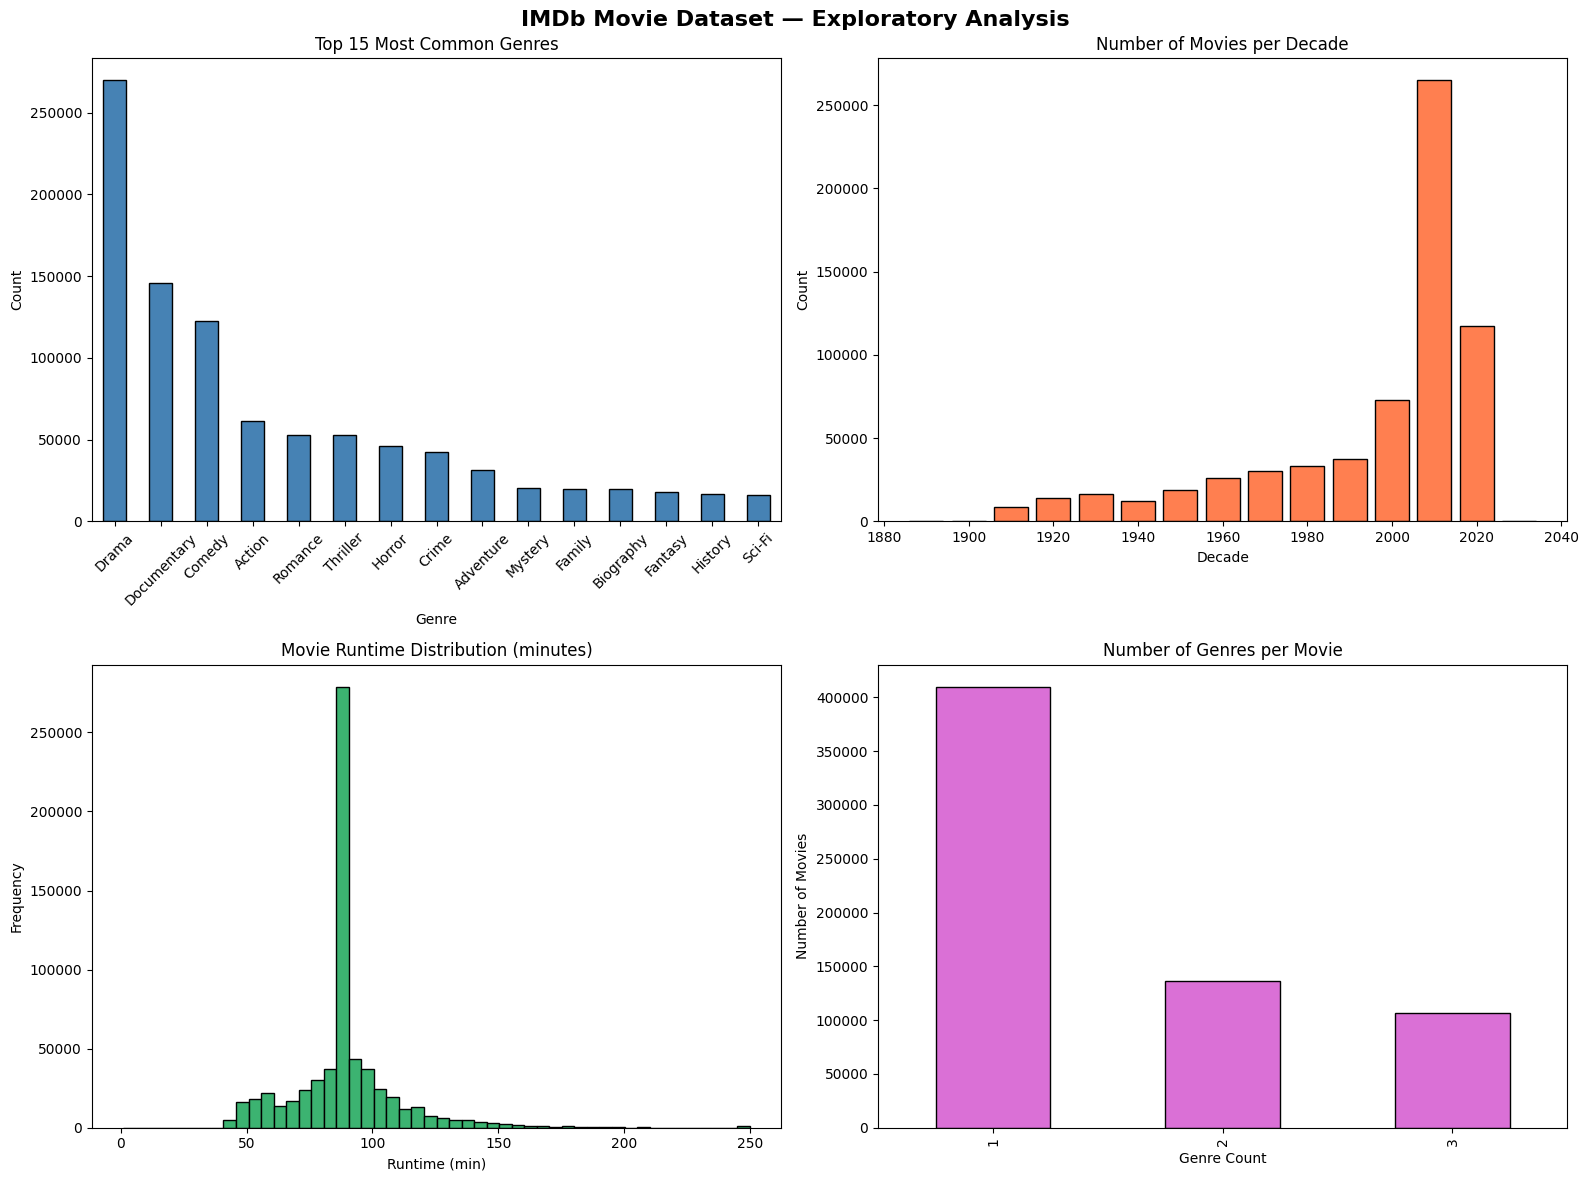

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('IMDb Movie Dataset — Exploratory Analysis', fontsize=16, fontweight='bold')

# Plot 1: Top Genres
all_genres = movies['genre_list'].explode()
genre_counts = all_genres.value_counts().head(15)
genre_counts.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Top 15 Most Common Genres')
axes[0,0].set_xlabel('Genre')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Movies per Decade
decade_counts = movies['decade'].value_counts().sort_index()
axes[0,1].bar(decade_counts.index, decade_counts.values, width=8, color='coral', edgecolor='black')
axes[0,1].set_title('Number of Movies per Decade')
axes[0,1].set_xlabel('Decade')
axes[0,1].set_ylabel('Count')

# Plot 3: Runtime Distribution
runtime_data = movies['runtimeMinutes'].clip(upper=250)
axes[1,0].hist(runtime_data, bins=50, color='mediumseagreen', edgecolor='black')
axes[1,0].set_title('Movie Runtime Distribution (minutes)')
axes[1,0].set_xlabel('Runtime (min)')
axes[1,0].set_ylabel('Frequency')

# Plot 4: Genre Count per Movie
movies['genre_count'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1,1], color='orchid', edgecolor='black'
)
axes[1,1].set_title('Number of Genres per Movie')
axes[1,1].set_xlabel('Genre Count')
axes[1,1].set_ylabel('Number of Movies')

plt.tight_layout()
plt.show()

---
## 🤖 Step 5: Algorithm 1 — Content-Based Filtering (TF-IDF + Cosine Similarity)

**Concept:** Represent each movie as a TF-IDF vector of its genre tags and decade. Recommend movies with the highest cosine similarity to the query movie.

In [13]:
# ─── Build TF-IDF Matrix ──────────────────────────────────────────────────────
print("Building TF-IDF matrix ...")
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['features'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print("✅ TF-IDF matrix built.")

Building TF-IDF matrix ...
TF-IDF matrix shape: (652680, 45)
✅ TF-IDF matrix built.


In [14]:
# ─── Build index mapping: title → row index ───────────────────────────────────
title_to_index = pd.Series(movies.index, index=movies['primaryTitle'].str.lower()).drop_duplicates()

def content_based_recommend(movie_title, top_n=10):
    """
    Content-Based Recommendation using TF-IDF + Cosine Similarity.

    Parameters
    ----------
    movie_title : str   — Title of the movie to base recommendations on
    top_n       : int   — Number of recommendations to return

    Returns
    -------
    DataFrame with recommended movies and their similarity scores.
    """
    movie_title_lower = movie_title.lower().strip()

    # Partial match if exact not found
    if movie_title_lower not in title_to_index:
        matches = [t for t in title_to_index.index if movie_title_lower in t]
        if not matches:
            print(f"❌ Movie '{movie_title}' not found in dataset.")
            return None
        movie_title_lower = matches[0]
        print(f"⚠️  Exact title not found. Using closest match: '{movies.loc[title_to_index[movie_title_lower], 'primaryTitle']}'")

    idx = title_to_index[movie_title_lower]
    query_vec = tfidf_matrix[idx:idx+1]

    # Cosine similarity with all movies
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Get top N (excluding itself)
    sim_indices = np.argsort(sim_scores)[::-1][1:top_n+1]

    result = movies.iloc[sim_indices][['primaryTitle', 'genres', 'startYear', 'runtimeMinutes']].copy()
    result['similarity_score'] = sim_scores[sim_indices].round(4)
    result.reset_index(drop=True, inplace=True)
    result.index += 1  # 1-based rank
    return result

print("✅ Content-Based Recommender ready.")

✅ Content-Based Recommender ready.


In [49]:
# ════════════════════════════════════════════════════════════
#  🎯 INPUT: Enter a movie title to get content-based recommendations
# ════════════════════════════════════════════════════════════
INPUT_MOVIE = input("Enter a movie title: ")   # ← Change this to any movie title
TOP_N       = 10

print(f"\n{'='*60}")
print(f" Content-Based Recommendations for: '{INPUT_MOVIE}'")
print(f"{'='*60}")
recs = content_based_recommend(INPUT_MOVIE, top_n=TOP_N)
if recs is not None:
    display(recs)


 Content-Based Recommendations for: 'The Fairylogue and Radio-Plays'


,primaryTitle,genres,startYear,runtimeMinutes,similarity_score
1,La malia dell'oro,Fantasy,1905.0,90.0,0.9362
2,Sonho de Valsa,"Adventure,Drama",1909.0,90.0,0.9016
3,Dingjun Mountain,Drama,1905.0,45.0,0.8304
4,S. Lubin's Passion Play,Drama,1903.0,60.0,0.8304
5,Violante,Drama,1907.0,90.0,0.8304
6,Excelsior,Drama,1909.0,90.0,0.8304
7,Locura de amor,Drama,1909.0,45.0,0.8304
8,El grito de Dolores o La independencia de México,Drama,1907.0,90.0,0.8304
9,Life of Christ,Drama,1907.0,99.0,0.8304
10,Don Quijote,Drama,1908.0,90.0,0.8304


---
## 🔗 Step 6: Algorithm 2 — Association Rule Mining (Apriori on Genres)

**Concept:** Treat each movie's genre list as a transaction. Apply Apriori to find frequently co-occurring genre combinations, then mine association rules.

In [50]:
# ─── Prepare genre transactions ───────────────────────────────────────────────
transactions = movies['genre_list'].tolist()

# Encode into boolean matrix
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
genre_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Transaction matrix shape: {genre_df.shape}")
print(f"Unique genres: {list(te.columns_)}")

Transaction matrix shape: (652680, 27)
Unique genres: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Talk-Show', 'Thriller', 'War', 'Western']


In [51]:
# ─── Run Apriori ──────────────────────────────────────────────────────────────
frequent_itemsets = apriori(genre_df, min_support=0.02, use_colnames=True)
frequent_itemsets.sort_values('support', ascending=False, inplace=True)
frequent_itemsets.reset_index(drop=True, inplace=True)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
display(frequent_itemsets.head(15))

Frequent itemsets found: 22


,support,itemsets
0,0.413172,(Drama)
1,0.223057,(Documentary)
2,0.187394,(Comedy)
3,0.093654,(Action)
4,0.081247,(Romance)
5,0.080557,(Thriller)
6,0.070207,(Horror)
7,0.065200,(Crime)
8,0.048365,(Adventure)
9,0.048129,"(Comedy, Drama)"


In [52]:
# ─── Generate Association Rules ───────────────────────────────────────────────
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.3)
rules.sort_values('lift', ascending=False, inplace=True)
rules.reset_index(drop=True, inplace=True)

print(f"Association rules mined: {len(rules)}")
display(rules[['antecedents','consequents','support','confidence','lift']].head(15))

Association rules mined: 4


,antecedents,consequents,support,confidence,lift
0,(Romance),(Comedy),0.026840,0.330354,1.762888
1,(Romance),(Drama),0.044342,0.545768,1.320923
2,(Crime),(Drama),0.032880,0.504289,1.220530
3,(Action),(Drama),0.028351,0.302719,0.732671


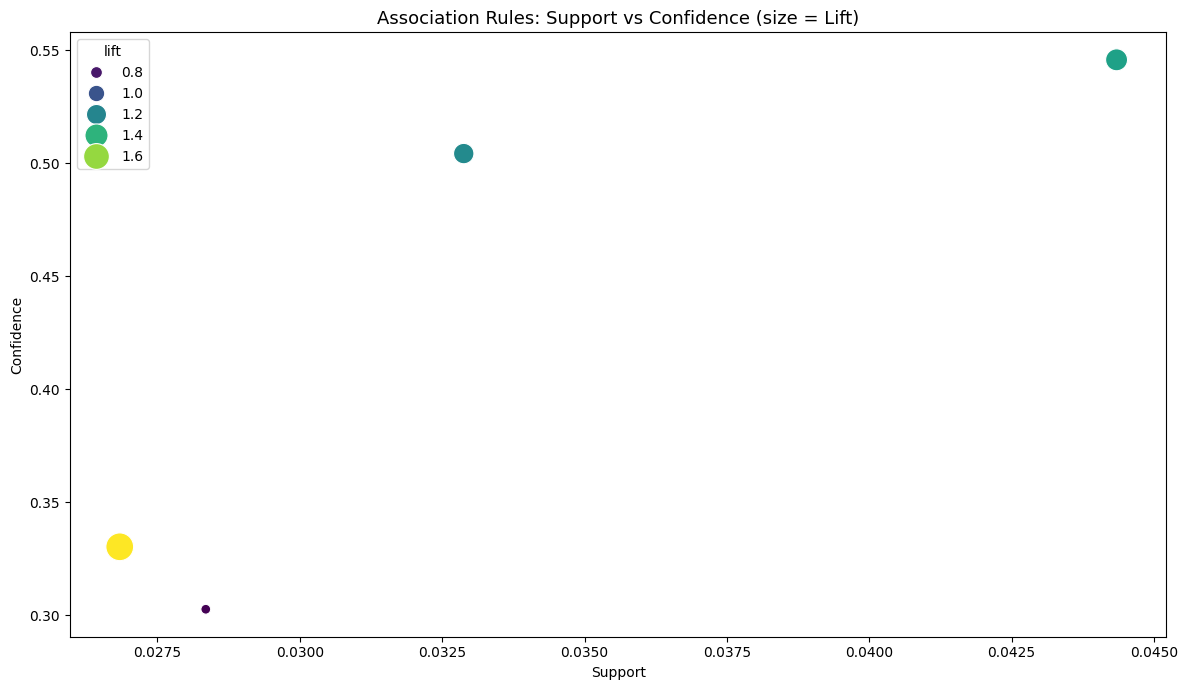

In [53]:
# ─── Visualise top rules ──────────────────────────────────────────────────────
top_rules = rules.head(20).copy()
top_rules['rule'] = (
    top_rules['antecedents'].apply(lambda x: ', '.join(list(x))) +
    ' → ' +
    top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
)

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=top_rules, x='support', y='confidence',
    size='lift', hue='lift', palette='viridis', sizes=(50, 400), legend='brief'
)
plt.title('Association Rules: Support vs Confidence (size = Lift)', fontsize=13)
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.tight_layout()
plt.show()

In [54]:
def genre_association_recommend(input_genres, top_n=5):
    """
    Recommend genres likely to co-occur using association rules.

    Parameters
    ----------
    input_genres : list  — e.g. ['Action', 'Drama']
    top_n        : int   — number of consequent genre rules to show

    Returns
    -------
    Filtered association rules + movie suggestions from consequent genres.
    """
    input_set = frozenset(input_genres)
    matched = rules[rules['antecedents'] == input_set].head(top_n)

    if matched.empty:
        # Try subset matching
        matched = rules[rules['antecedents'].apply(lambda x: x.issubset(input_set))].head(top_n)

    if matched.empty:
        print(f"❌ No rules found for genres: {input_genres}")
        return

    print(f"\n📐 Association Rules for genres {input_genres}:")
    display(matched[['antecedents','consequents','support','confidence','lift']])

    # Collect consequent genres
    consequent_genres = set()
    for g in matched['consequents']:
        consequent_genres.update(g)

    print(f"\n🎬 Movies matching associated genres {consequent_genres}:")
    mask = movies['genre_list'].apply(lambda gl: bool(consequent_genres & set(gl)))
    result = movies[mask][['primaryTitle','genres','startYear','runtimeMinutes']].head(top_n * 2)
    result.reset_index(drop=True, inplace=True)
    result.index += 1
    display(result)

print("✅ Association Rule Recommender ready.")

✅ Association Rule Recommender ready.


In [57]:
# ════════════════════════════════════════════════════════════
#  🎯 INPUT: Enter genres to find associated genre rules
# ════════════════════════════════════════════════════════════
INPUT_GENRES = ['Documentary']   # ← Change these genre(s)

print(f"\n{'='*60}")
print(f" Genre Association Recommendations for: {INPUT_GENRES}")
print(f"{'='*60}")
genre_association_recommend(INPUT_GENRES, top_n=5)


 Genre Association Recommendations for: ['Documentary']
❌ No rules found for genres: ['Documentary']


---
## 📈 Step 7: Algorithm 3 — Popularity-Based Recommendation

**Concept:** Rank movies by a weighted popularity score derived from runtime, recency, and genre diversity. Useful as a cold-start recommendation (no user history needed).

In [58]:
# ─── Compute popularity score ─────────────────────────────────────────────────
scaler2 = MinMaxScaler()

movies['year_scaled']    = scaler2.fit_transform(movies[['startYear']])
movies['runtime_scaled'] = scaler2.fit_transform(movies[['runtimeMinutes']])
movies['genre_scaled']   = scaler2.fit_transform(movies[['genre_count']])

# Weighted popularity: recency 40%, runtime 35%, genre diversity 25%
movies['weighted_popularity'] = (
    0.40 * movies['year_scaled'] +
    0.35 * movies['runtime_scaled'] +
    0.25 * movies['genre_scaled']
).round(4)

def popularity_recommend(genre_filter=None, top_n=10):
    """
    Popularity-Based Recommendation.

    Parameters
    ----------
    genre_filter : str or None  — Filter by a specific genre (e.g. 'Action')
    top_n        : int          — Number of top movies to return

    Returns
    -------
    Top-ranked movies by weighted popularity score.
    """
    df = movies.copy()
    if genre_filter:
        df = df[df['genre_list'].apply(lambda g: genre_filter.capitalize() in g)]
        if df.empty:
            print(f"❌ No movies found for genre: {genre_filter}")
            return

    result = df.nlargest(top_n, 'weighted_popularity')[[
        'primaryTitle','genres','startYear','runtimeMinutes','weighted_popularity'
    ]].copy()
    result.reset_index(drop=True, inplace=True)
    result.index += 1
    return result

print("✅ Popularity-Based Recommender ready.")

✅ Popularity-Based Recommender ready.


In [59]:
# ════════════════════════════════════════════════════════════
#  🎯 INPUT: Set genre filter (or None for all genres)
# ════════════════════════════════════════════════════════════
GENRE_FILTER = input("Enter a genre (or leave blank for all): ")
TOP_N_POP    = 10

print(f"\n{'='*60}")
print(f" Top {TOP_N_POP} Popular Movies" + (f" in Genre: '{GENRE_FILTER}'" if GENRE_FILTER else " (All Genres)"))
print(f"{'='*60}")
pop_recs = popularity_recommend(genre_filter=GENRE_FILTER, top_n=TOP_N_POP)
if pop_recs is not None:
    display(pop_recs)


 Top 10 Popular Movies in Genre: 'Documentary'


,primaryTitle,genres,startYear,runtimeMinutes,weighted_popularity
1,Logistics,Documentary,2012.0,51420.0,0.6945
2,Ambiancé,Documentary,2020.0,43200.0,0.6619
3,Inflammingo,"Biography,Documentary,Drama",2027.0,107.0,0.6390
4,Bell to Bell,"Documentary,Drama,Sport",2027.0,90.0,0.6389
5,Bradford Bears,"Documentary,Drama,Sport",2027.0,68.0,0.6388
6,Waldheim-KGB Agent Kurt,"Biography,Documentary,History",2026.0,201.0,0.6368
7,Chronos - Flow of Time,"Biography,Documentary,History",2026.0,200.0,0.6368
8,Herbstfeuer,"Crime,Documentary,Drama",2026.0,114.0,0.6362
9,Infinite Icon: A Visual Memoir,"Biography,Documentary,Music",2026.0,117.0,0.6362
10,Paralyzed by Hope: The Maria Bamford Story,"Biography,Comedy,Documentary",2026.0,116.0,0.6362


---
## 🧩 Step 8: Algorithm 4 — K-Means Clustering of Movies

**Concept:** Cluster movies into groups based on their TF-IDF feature vectors using K-Means. Recommend movies from the same cluster as the queried movie.

Reducing TF-IDF dimensions with SVD ...
Reduced shape: (652680, 44)
Running elbow method ...


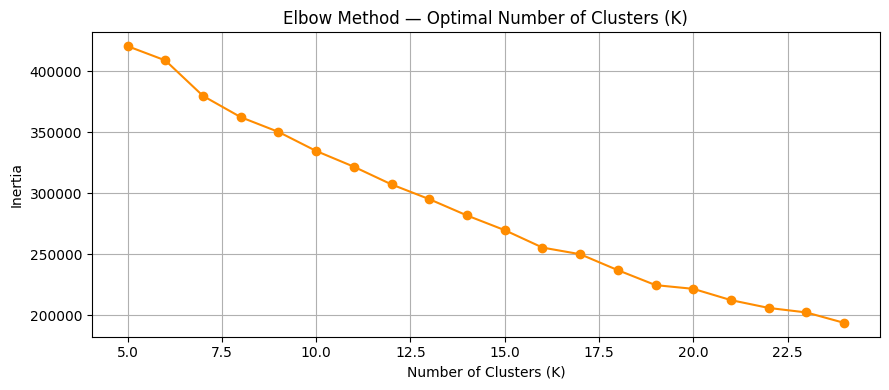

In [25]:
# ─── Dimensionality reduction before clustering ───────────────────────────────
print("Reducing TF-IDF dimensions with SVD ...")
svd = TruncatedSVD(n_components=44, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)
print(f"Reduced shape: {tfidf_reduced.shape}")

# ─── Elbow Method to choose optimal K ────────────────────────────────────────
inertias = []
K_range = range(5, 25)

print("Running elbow method ...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    km.fit(tfidf_reduced)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, marker='o', color='darkorange')
plt.title('Elbow Method — Optimal Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# ─── Fit K-Means with chosen K ───────────────────────────────────────────────
OPTIMAL_K = 12   # ← Adjust based on elbow plot

print(f"Fitting K-Means with K={OPTIMAL_K} ...")
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
movies['cluster'] = kmeans.fit_predict(tfidf_reduced)

print("\nCluster distribution:")
print(movies['cluster'].value_counts().sort_index())

# ─── Inspect dominant genres per cluster ─────────────────────────────────────
print("\n=== Dominant Genres per Cluster ===")
for c in range(OPTIMAL_K):
    cluster_movies = movies[movies['cluster'] == c]
    top_genres = cluster_movies['genre_list'].explode().value_counts().head(3).index.tolist()
    print(f"  Cluster {c:2d} ({len(cluster_movies):5d} movies) → {top_genres}")

Fitting K-Means with K=12 ...

Cluster distribution:
cluster
0      72400
1      40714
2     141342
3      51758
4      17756
5      62226
6      76711
7      18464
8      39484
9      25557
10     32159
11     74109
Name: count, dtype: int64

=== Dominant Genres per Cluster ===
  Cluster  0 (72400 movies) → ['Documentary', 'Biography', 'History']
  Cluster  1 (40714 movies) → ['Horror', 'Thriller', 'Drama']
  Cluster  2 (141342 movies) → ['Drama', 'Action', 'Crime']
  Cluster  3 (51758 movies) → ['Drama', 'Romance']
  Cluster  4 (17756 movies) → ['Fantasy', 'Drama', 'Comedy']
  Cluster  5 (62226 movies) → ['Drama', 'Documentary', 'Comedy']
  Cluster  6 (76711 movies) → ['Comedy', 'Drama', 'Romance']
  Cluster  7 (18464 movies) → ['Drama', 'Comedy', 'Romance']
  Cluster  8 (39484 movies) → ['Thriller', 'Drama', 'Crime']
  Cluster  9 (25557 movies) → ['Drama', 'Comedy', 'Romance']
  Cluster 10 (32159 movies) → ['Drama', 'Comedy', 'Action']
  Cluster 11 (74109 movies) → ['Documentary', '

In [27]:
def cluster_recommend(movie_title, top_n=10):
    """
    Cluster-Based Recommendation using K-Means.

    Parameters
    ----------
    movie_title : str  — The query movie title
    top_n       : int  — Number of movies to return from the same cluster

    Returns
    -------
    DataFrame of movies in the same K-Means cluster.
    """
    movie_title_lower = movie_title.lower().strip()

    if movie_title_lower not in title_to_index:
        matches = [t for t in title_to_index.index if movie_title_lower in t]
        if not matches:
            print(f"❌ Movie '{movie_title}' not found.")
            return None
        movie_title_lower = matches[0]
        print(f"⚠️  Using closest match: '{movies.loc[title_to_index[movie_title_lower], 'primaryTitle']}'")

    idx = title_to_index[movie_title_lower]
    movie_cluster = movies.loc[idx, 'cluster']

    same_cluster = movies[
        (movies['cluster'] == movie_cluster) & (movies.index != idx)
    ].copy()

    # Sort by popularity within cluster
    same_cluster.sort_values('weighted_popularity', ascending=False, inplace=True)

    result = same_cluster[['primaryTitle','genres','startYear','runtimeMinutes','weighted_popularity']].head(top_n).copy()
    result.reset_index(drop=True, inplace=True)
    result.index += 1
    print(f"📌 Movie Cluster: {movie_cluster}")
    return result

print("✅ Cluster-Based Recommender ready.")

✅ Cluster-Based Recommender ready.


In [28]:
# ════════════════════════════════════════════════════════════
#  🎯 INPUT: Movie title for cluster-based recommendation
# ════════════════════════════════════════════════════════════
INPUT_MOVIE_CLUSTER = "Miss Jerry"   # ← Change this
TOP_N_CLUSTER       = 10

print(f"\n{'='*60}")
print(f" Cluster-Based Recommendations for: '{INPUT_MOVIE_CLUSTER}'")
print(f"{'='*60}")
clus_recs = cluster_recommend(INPUT_MOVIE_CLUSTER, top_n=TOP_N_CLUSTER)
if clus_recs is not None:
    display(clus_recs)


 Cluster-Based Recommendations for: 'Miss Jerry'
📌 Movie Cluster: 2


,primaryTitle,genres,startYear,runtimeMinutes,weighted_popularity
1,Luciferum,"Action,Adventure,Drama",2031.0,90.0,0.6506
2,Untitled KPop Demon Hunters Sequel,"Action,Adventure,Animation",2029.0,90.0,0.6448
3,Coco 2,"Adventure,Animation,Drama",2029.0,90.0,0.6448
4,Fast Forever,"Action,Adventure,Crime",2028.0,90.0,0.6418
5,The Ron Movie,"Action,Adventure,Animation",2027.0,108.0,0.6390
6,Naya Legend of the Golden Dolphin,"Action,Adventure,Animation",2027.0,100.0,0.6390
7,Miami Vice,"Action,Crime,Drama",2027.0,90.0,0.6389
8,Otel «U pogibshego alpinista»,"Drama,Mystery,Sci-Fi",2027.0,90.0,0.6389
9,The Nightingale,"Drama,History,War",2027.0,90.0,0.6389
10,Spirit,"Action,Crime,Drama",2027.0,90.0,0.6389


---
## 🔀 Step 9: Algorithm 5 — Hybrid Recommender

**Concept:** Combine **Content-Based similarity** and **Popularity score** into a single weighted hybrid score to produce more balanced and relevant recommendations.

In [29]:
def hybrid_recommend(movie_title, top_n=10, content_weight=0.7, popularity_weight=0.3):
    """
    Hybrid Recommendation = Content Similarity × weight + Popularity × weight.

    Parameters
    ----------
    movie_title        : str   — Input movie title
    top_n              : int   — Number of results to return
    content_weight     : float — Weight for content similarity (0–1)
    popularity_weight  : float — Weight for popularity score (0–1)

    Returns
    -------
    DataFrame with hybrid-ranked recommendations.
    """
    assert abs(content_weight + popularity_weight - 1.0) < 1e-6, "Weights must sum to 1"

    movie_title_lower = movie_title.lower().strip()
    if movie_title_lower not in title_to_index:
        matches = [t for t in title_to_index.index if movie_title_lower in t]
        if not matches:
            print(f"❌ Movie '{movie_title}' not found.")
            return None
        movie_title_lower = matches[0]
        print(f"⚠️  Using closest match: '{movies.loc[title_to_index[movie_title_lower], 'primaryTitle']}'")

    idx = title_to_index[movie_title_lower]
    query_vec = tfidf_matrix[idx]

    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Normalise sim scores to [0,1]
    sim_norm = (sim_scores - sim_scores.min()) / (sim_scores.max() - sim_scores.min() + 1e-9)
    pop_norm = movies['weighted_popularity'].values

    hybrid_scores = content_weight * sim_norm + popularity_weight * pop_norm
    hybrid_scores[idx] = -1  # exclude itself

    top_indices = np.argsort(hybrid_scores)[::-1][:top_n]

    result = movies.iloc[top_indices][['primaryTitle','genres','startYear','runtimeMinutes']].copy()
    result['hybrid_score']   = hybrid_scores[top_indices].round(4)
    result['content_sim']    = sim_norm[top_indices].round(4)
    result['popularity']     = pop_norm[top_indices].round(4)
    result.reset_index(drop=True, inplace=True)
    result.index += 1
    return result

print("✅ Hybrid Recommender ready.")

✅ Hybrid Recommender ready.


In [30]:
# ════════════════════════════════════════════════════════════
#  🎯 INPUT: Movie title + weights for hybrid recommender
# ════════════════════════════════════════════════════════════
INPUT_MOVIE_HYBRID   = "Miss Jerry"  # ← Change this
TOP_N_HYBRID         = 10
CONTENT_WEIGHT       = 0.7           # ← Content vs Popularity balance
POPULARITY_WEIGHT    = 0.3

print(f"\n{'='*60}")
print(f" Hybrid Recommendations for: '{INPUT_MOVIE_HYBRID}'")
print(f" (Content={CONTENT_WEIGHT*100:.0f}% | Popularity={POPULARITY_WEIGHT*100:.0f}%)")
print(f"{'='*60}")
hybrid_recs = hybrid_recommend(
    INPUT_MOVIE_HYBRID,
    top_n=TOP_N_HYBRID,
    content_weight=CONTENT_WEIGHT,
    popularity_weight=POPULARITY_WEIGHT
)
if hybrid_recs is not None:
    display(hybrid_recs)


 Hybrid Recommendations for: 'Miss Jerry'
 (Content=70% | Popularity=30%)


,primaryTitle,genres,startYear,runtimeMinutes,hybrid_score,content_sim,popularity
1,Professor Billy Opperman's Swimming School,Documentary,1899.0,90.0,0.6584,0.934,0.0152
2,"2nd Company Governor's Footguards, Conn.",Documentary,1899.0,90.0,0.6584,0.934,0.0152
3,O Cortejo da Procissão da Senhora da Saúde,Documentary,1899.0,90.0,0.6584,0.934,0.0152
4,O Lançamento ao Tejo do Cruzador 'Rainha D. Am...,Documentary,1899.0,90.0,0.6584,0.934,0.0152
5,A Procissão da Semana Santa,Documentary,1899.0,90.0,0.6584,0.934,0.0152
6,69th Regiment Passing in Review,Documentary,1898.0,90.0,0.6575,0.934,0.0123
7,O Campo Grande,Documentary,1898.0,90.0,0.6575,0.934,0.0123
8,A Rua Augusta em Dia de Festa,Documentary,1898.0,90.0,0.6575,0.934,0.0123
9,O Carnaval em Lisboa,Documentary,1898.0,90.0,0.6575,0.934,0.0123
10,Dressing Paper Dolls,Documentary,1898.0,90.0,0.6575,0.934,0.0123


---
## 🎛️ Step 10: Unified Recommendation Interface

A single entry point combining all algorithms.

In [31]:
def recommend(movie_title=None, genre=None, mode='hybrid', top_n=10):
    """
    ╔══════════════════════════════════════════════════════════╗
    ║          UNIFIED MOVIE RECOMMENDATION SYSTEM            ║
    ║     Using Data Mining to Recommend Movies to Viewers    ║
    ╚══════════════════════════════════════════════════════════╝

    Parameters
    ----------
    movie_title : str   — Movie name (for content/cluster/hybrid modes)
    genre       : str   — Genre name (for popularity/association modes)
    mode        : str   — One of: 'content', 'popularity', 'cluster',
                                   'association', 'hybrid'
    top_n       : int   — Number of recommendations

    Returns
    -------
    DataFrame of recommended movies.
    """
    print(f"\n{'═'*65}")
    print(f"  🎬 Movie Recommendation System  |  Mode: {mode.upper()}")
    print(f"{'═'*65}")

    if mode == 'content':
        if not movie_title:
            print("❌ Please provide a movie_title for content-based mode.")
            return
        print(f"  🔍 Based on: '{movie_title}'  |  Top {top_n} content-similar movies")
        result = content_based_recommend(movie_title, top_n)

    elif mode == 'popularity':
        print(f"  🔝 Top {top_n} popular movies" + (f" in genre '{genre}'" if genre else ""))
        result = popularity_recommend(genre_filter=genre, top_n=top_n)

    elif mode == 'cluster':
        if not movie_title:
            print("❌ Please provide a movie_title for cluster mode.")
            return
        print(f"  🔍 Cluster neighbours of: '{movie_title}'  |  Top {top_n}")
        result = cluster_recommend(movie_title, top_n)

    elif mode == 'association':
        if not genre:
            print("❌ Please provide genre(s) for association mode (as a list).")
            return
        genre_list = [genre] if isinstance(genre, str) else genre
        print(f"  🔗 Genre association rules for: {genre_list}")
        genre_association_recommend(genre_list, top_n)
        return

    elif mode == 'hybrid':
        if not movie_title:
            print("❌ Please provide a movie_title for hybrid mode.")
            return
        print(f"  ⚡ Hybrid (70% content + 30% popularity) for: '{movie_title}'")
        result = hybrid_recommend(movie_title, top_n)

    else:
        print(f"❌ Unknown mode '{mode}'. Choose: content / popularity / cluster / association / hybrid")
        return

    if result is not None:
        print(f"{'─'*65}")
        display(result)
        print(f"{'═'*65}\n")
    return result

print("✅ Unified recommend() function ready!")

✅ Unified recommend() function ready!


In [32]:
# ════════════════════════════════════════════════════════════
#  🎯 DEMO — Try all modes
# ════════════════════════════════════════════════════════════

# 1️⃣  Content-Based
recommend(movie_title="Miss Jerry", mode='content', top_n=10)


═════════════════════════════════════════════════════════════════
  🎬 Movie Recommendation System  |  Mode: CONTENT
═════════════════════════════════════════════════════════════════
  🔍 Based on: 'Miss Jerry'  |  Top 10 content-similar movies
─────────────────────────────────────────────────────────────────


,primaryTitle,genres,startYear,runtimeMinutes,similarity_score
1,69th Regiment Passing in Review,Documentary,1898.0,90.0,0.934
2,O Campo Grande,Documentary,1898.0,90.0,0.934
3,O Cortejo da Procissão da Senhora da Saúde,Documentary,1899.0,90.0,0.934
4,"2nd Company Governor's Footguards, Conn.",Documentary,1899.0,90.0,0.934
5,O Lançamento ao Tejo do Cruzador 'Rainha D. Am...,Documentary,1899.0,90.0,0.934
6,Birmingham,Documentary,1896.0,61.0,0.934
7,A Procissão da Semana Santa,Documentary,1899.0,90.0,0.934
8,A Rua Augusta em Dia de Festa,Documentary,1898.0,90.0,0.934
9,Saída dos Operários do Arsenal da Marinha,Documentary,1898.0,90.0,0.934
10,Dressing Paper Dolls,Documentary,1898.0,90.0,0.934


═════════════════════════════════════════════════════════════════



,primaryTitle,genres,startYear,runtimeMinutes,similarity_score
1,69th Regiment Passing in Review,Documentary,1898.0,90.0,0.934
2,O Campo Grande,Documentary,1898.0,90.0,0.934
3,O Cortejo da Procissão da Senhora da Saúde,Documentary,1899.0,90.0,0.934
4,"2nd Company Governor's Footguards, Conn.",Documentary,1899.0,90.0,0.934
5,O Lançamento ao Tejo do Cruzador 'Rainha D. Am...,Documentary,1899.0,90.0,0.934
6,Birmingham,Documentary,1896.0,61.0,0.934
7,A Procissão da Semana Santa,Documentary,1899.0,90.0,0.934
8,A Rua Augusta em Dia de Festa,Documentary,1898.0,90.0,0.934
9,Saída dos Operários do Arsenal da Marinha,Documentary,1898.0,90.0,0.934
10,Dressing Paper Dolls,Documentary,1898.0,90.0,0.934


In [33]:
# 2️⃣  Popularity-Based (filter by genre)
recommend(genre='Romance', mode='popularity', top_n=10)


═════════════════════════════════════════════════════════════════
  🎬 Movie Recommendation System  |  Mode: POPULARITY
═════════════════════════════════════════════════════════════════
  🔝 Top 10 popular movies in genre 'Romance'
─────────────────────────────────────────────────────────────────


,primaryTitle,genres,startYear,runtimeMinutes,weighted_popularity
1,Owner of GJ39,"Action,Romance,Thriller",2027.0,90.0,0.6389
2,The Thomas Crown Affair,"Crime,Drama,Romance",2027.0,90.0,0.6389
3,Sarkari Damad,"Comedy,Drama,Romance",2026.0,170.0,0.6366
4,Poyla Baishakh,"Action,Romance,Sci-Fi",2026.0,159.0,0.6365
5,LIK: Love Insurance Kompany,"Comedy,Romance,Sci-Fi",2026.0,150.0,0.6364
6,With Love,"Comedy,Drama,Romance",2026.0,141.0,0.6364
7,Sweety Naughty Crazy,"Comedy,Drama,Romance",2026.0,142.0,0.6364
8,Laagni No Melo,"Drama,Family,Romance",2026.0,153.0,0.6364
9,The Bride!,"Drama,Horror,Romance",2026.0,126.0,0.6363
10,Kadhal Reset Repeat,"Comedy,Drama,Romance",2026.0,135.0,0.6363


═════════════════════════════════════════════════════════════════



,primaryTitle,genres,startYear,runtimeMinutes,weighted_popularity
1,Owner of GJ39,"Action,Romance,Thriller",2027.0,90.0,0.6389
2,The Thomas Crown Affair,"Crime,Drama,Romance",2027.0,90.0,0.6389
3,Sarkari Damad,"Comedy,Drama,Romance",2026.0,170.0,0.6366
4,Poyla Baishakh,"Action,Romance,Sci-Fi",2026.0,159.0,0.6365
5,LIK: Love Insurance Kompany,"Comedy,Romance,Sci-Fi",2026.0,150.0,0.6364
6,With Love,"Comedy,Drama,Romance",2026.0,141.0,0.6364
7,Sweety Naughty Crazy,"Comedy,Drama,Romance",2026.0,142.0,0.6364
8,Laagni No Melo,"Drama,Family,Romance",2026.0,153.0,0.6364
9,The Bride!,"Drama,Horror,Romance",2026.0,126.0,0.6363
10,Kadhal Reset Repeat,"Comedy,Drama,Romance",2026.0,135.0,0.6363


In [34]:
# 3️⃣  Association Rule-Based
recommend(genre=['Drama'], mode='association', top_n=5)


═════════════════════════════════════════════════════════════════
  🎬 Movie Recommendation System  |  Mode: ASSOCIATION
═════════════════════════════════════════════════════════════════
  🔗 Genre association rules for: ['Drama']
❌ No rules found for genres: ['Drama']


In [35]:
# 4️⃣  Cluster-Based
recommend(movie_title="Miss Jerry", mode='cluster', top_n=10)


═════════════════════════════════════════════════════════════════
  🎬 Movie Recommendation System  |  Mode: CLUSTER
═════════════════════════════════════════════════════════════════
  🔍 Cluster neighbours of: 'Miss Jerry'  |  Top 10
📌 Movie Cluster: 2
─────────────────────────────────────────────────────────────────


,primaryTitle,genres,startYear,runtimeMinutes,weighted_popularity
1,Luciferum,"Action,Adventure,Drama",2031.0,90.0,0.6506
2,Untitled KPop Demon Hunters Sequel,"Action,Adventure,Animation",2029.0,90.0,0.6448
3,Coco 2,"Adventure,Animation,Drama",2029.0,90.0,0.6448
4,Fast Forever,"Action,Adventure,Crime",2028.0,90.0,0.6418
5,The Ron Movie,"Action,Adventure,Animation",2027.0,108.0,0.6390
6,Naya Legend of the Golden Dolphin,"Action,Adventure,Animation",2027.0,100.0,0.6390
7,Miami Vice,"Action,Crime,Drama",2027.0,90.0,0.6389
8,Otel «U pogibshego alpinista»,"Drama,Mystery,Sci-Fi",2027.0,90.0,0.6389
9,The Nightingale,"Drama,History,War",2027.0,90.0,0.6389
10,Spirit,"Action,Crime,Drama",2027.0,90.0,0.6389


═════════════════════════════════════════════════════════════════



,primaryTitle,genres,startYear,runtimeMinutes,weighted_popularity
1,Luciferum,"Action,Adventure,Drama",2031.0,90.0,0.6506
2,Untitled KPop Demon Hunters Sequel,"Action,Adventure,Animation",2029.0,90.0,0.6448
3,Coco 2,"Adventure,Animation,Drama",2029.0,90.0,0.6448
4,Fast Forever,"Action,Adventure,Crime",2028.0,90.0,0.6418
5,The Ron Movie,"Action,Adventure,Animation",2027.0,108.0,0.6390
6,Naya Legend of the Golden Dolphin,"Action,Adventure,Animation",2027.0,100.0,0.6390
7,Miami Vice,"Action,Crime,Drama",2027.0,90.0,0.6389
8,Otel «U pogibshego alpinista»,"Drama,Mystery,Sci-Fi",2027.0,90.0,0.6389
9,The Nightingale,"Drama,History,War",2027.0,90.0,0.6389
10,Spirit,"Action,Crime,Drama",2027.0,90.0,0.6389


In [36]:
# 5️⃣  Hybrid (best of all worlds)
recommend(movie_title="Miss Jerry", mode='hybrid', top_n=10)


═════════════════════════════════════════════════════════════════
  🎬 Movie Recommendation System  |  Mode: HYBRID
═════════════════════════════════════════════════════════════════
  ⚡ Hybrid (70% content + 30% popularity) for: 'Miss Jerry'
─────────────────────────────────────────────────────────────────


,primaryTitle,genres,startYear,runtimeMinutes,hybrid_score,content_sim,popularity
1,Professor Billy Opperman's Swimming School,Documentary,1899.0,90.0,0.6584,0.934,0.0152
2,"2nd Company Governor's Footguards, Conn.",Documentary,1899.0,90.0,0.6584,0.934,0.0152
3,O Cortejo da Procissão da Senhora da Saúde,Documentary,1899.0,90.0,0.6584,0.934,0.0152
4,O Lançamento ao Tejo do Cruzador 'Rainha D. Am...,Documentary,1899.0,90.0,0.6584,0.934,0.0152
5,A Procissão da Semana Santa,Documentary,1899.0,90.0,0.6584,0.934,0.0152
6,69th Regiment Passing in Review,Documentary,1898.0,90.0,0.6575,0.934,0.0123
7,O Campo Grande,Documentary,1898.0,90.0,0.6575,0.934,0.0123
8,A Rua Augusta em Dia de Festa,Documentary,1898.0,90.0,0.6575,0.934,0.0123
9,O Carnaval em Lisboa,Documentary,1898.0,90.0,0.6575,0.934,0.0123
10,Dressing Paper Dolls,Documentary,1898.0,90.0,0.6575,0.934,0.0123


═════════════════════════════════════════════════════════════════



,primaryTitle,genres,startYear,runtimeMinutes,hybrid_score,content_sim,popularity
1,Professor Billy Opperman's Swimming School,Documentary,1899.0,90.0,0.6584,0.934,0.0152
2,"2nd Company Governor's Footguards, Conn.",Documentary,1899.0,90.0,0.6584,0.934,0.0152
3,O Cortejo da Procissão da Senhora da Saúde,Documentary,1899.0,90.0,0.6584,0.934,0.0152
4,O Lançamento ao Tejo do Cruzador 'Rainha D. Am...,Documentary,1899.0,90.0,0.6584,0.934,0.0152
5,A Procissão da Semana Santa,Documentary,1899.0,90.0,0.6584,0.934,0.0152
6,69th Regiment Passing in Review,Documentary,1898.0,90.0,0.6575,0.934,0.0123
7,O Campo Grande,Documentary,1898.0,90.0,0.6575,0.934,0.0123
8,A Rua Augusta em Dia de Festa,Documentary,1898.0,90.0,0.6575,0.934,0.0123
9,O Carnaval em Lisboa,Documentary,1898.0,90.0,0.6575,0.934,0.0123
10,Dressing Paper Dolls,Documentary,1898.0,90.0,0.6575,0.934,0.0123


---
## 📝 Step 11: Summary & Evaluation

### Algorithms Used

| # | Algorithm | Technique | Input | Output |
|---|-----------|-----------|-------|--------|
| 1 | Content-Based Filtering | TF-IDF + Cosine Similarity | Movie title | Similar movies |
| 2 | Association Rule Mining | Apriori on genre transactions | Genre(s) | Related genres + movies |
| 3 | Popularity-Based | Weighted scoring (year, runtime, genres) | Genre (optional) | Top-ranked movies |
| 4 | Cluster-Based | K-Means + SVD | Movie title | Movies in same cluster |
| 5 | Hybrid | Weighted combination of #1 + #3 | Movie title | Best balanced recommendations |

### Preprocessing Steps Applied
- Filtered to `titleType == 'movie'` only
- Removed adult content (`isAdult == 1`)
- Handled `\N` null values throughout
- Converted numeric columns (`startYear`, `runtimeMinutes`)
- Median imputation for missing numerics
- Removed duplicates on `tconst`
- Engineered: `genre_list`, `decade`, `features`, `popularity_score`

### Data Mining Concepts Applied
- **TF-IDF vectorisation** for feature representation
- **Cosine similarity** for distance measurement
- **Apriori algorithm** for frequent itemset mining
- **Association rules** (support, confidence, lift)
- **K-Means clustering** for grouping
- **SVD / dimensionality reduction** before clustering
- **Min-Max normalisation** for score blending

In [37]:
# ─── Final dataset stats ──────────────────────────────────────────────────────
print("=" * 55)
print(" FINAL PROJECT STATISTICS")
print("=" * 55)
print(f"  Total movies in dataset      : {len(movies):,}")
print(f"  Unique genres                : {len(all_genres.unique())}")
print(f"  Year range                   : {int(movies['startYear'].min())} – {int(movies['startYear'].max())}")
print(f"  Avg runtime (min)            : {movies['runtimeMinutes'].mean():.1f}")
print(f"  K-Means clusters             : {OPTIMAL_K}")
print(f"  Frequent itemsets (Apriori)  : {len(frequent_itemsets)}")
print(f"  Association rules mined      : {len(rules)}")
print("=" * 55)
print("\n✅ Movie Recommendation System project complete!")

 FINAL PROJECT STATISTICS
  Total movies in dataset      : 652,680
  Unique genres                : 27
  Year range                   : 1894 – 2031
  Avg runtime (min)            : 90.3
  K-Means clusters             : 12
  Frequent itemsets (Apriori)  : 22
  Association rules mined      : 4

✅ Movie Recommendation System project complete!
